# QA to compare with MEM1

In [2]:
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
import pdb
import numpy as np

ABBEL_file = "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/nqhotpotqa_grpo_qwen2.5-7b-instruct_16sfr_seed1_sc_False_belief_prompting_TrueGRPO_INSTRUCT/train_gen.txt"
ABBEL_file = "/nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/nqhotpotqa_grpo_qwen2.5-7b-instruct_t_1.0_256sfr_seed1_sc_False_belief_prompting_True_ckpt__seed1_sc_False_belief_prompting_TrueGRPO_INSTRUCT/global_step_260_objectives_8_inference/train_gen.txt"
MEM1_file = "/home/jbjorner3/storage/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/nqhotpotqa_grpo_qwen2.5-7b-instruct_t_0.01_256sfr_seed1_sc_False_belief_prompting_True_ckpt_qwen2.5-7b-instruct_16sfr_seed1_sc_False_belief_prompting_True_is_mem1_TrueGRPO_INSTRUCT/global_step_260_objectives_16_inference/train_gen.txt"

def get_df_from_train_gen(file: str):
    raw_jl = open(file, 'r', encoding='utf-8').read()

    import json, sys, pathlib

    json_list = []
    for i, raw_json in enumerate(raw_jl.strip().split("\n}")):
        if raw_json.strip():
            json_list.append(json.loads(raw_json + "\n}"))
    df = pd.DataFrame(json_list)
    return df



In [65]:
dfraw = get_df_from_train_gen('/nas/ucb/dayan/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/nqhotpotqa_grpo_qwen2.5-7b-instruct_16sfr_seed1_sc_False_belief_prompting_True_is_mem1_False_belief_len_pen_0.0GRPO_INSTRUCT/train_gen.txt')
trainingdf = pd.DataFrame(dfraw.iloc[-1].to_dict())

In [66]:
trainingdf = pd.DataFrame(dfraw.iloc[-1].to_dict())

In [69]:
ts = compute_peak_token_all_trajectories(trainingdf,'ABBEL')
np.mean(ts)

np.float64(712.4736842105264)

In [61]:
trainingdf.groupby('traj_uid').rewards.max().mean()

np.float64(0.5625)

In [68]:
count = 0
for i, traj_df in trainingdf.groupby('traj_uid'):
    if traj_df.rewards.max() > -1:
        count +=1
        if count == 1:
            break

pprint(traj_df.sort_values(by='step').iloc[0].full_trajectory_strings)
traj_df.rewards.max()

('system\n'
 'You will answer multiple complex questions using iterative reasoning, and '
 'web search.\n'
 'When taking an action, choose from one of the following actions:\n'
 '   - If any question remains unanswered, issue a single query for one '
 'question inside <search> ... </search>. The query should consist of keywords '
 'or a short phrase. Only search one question at a time.\n'
 '   - If all questions are answered, provide the final answers—separated by '
 'semicolons—within <answer> answer1; answer2; ... </answer>. The answers must '
 'be concise, contain only essential words, and avoid any explanations.\n'
 '\n'
 'Important:\n'
 '- Do not search multiple queries or questions simultaneously.\n'
 '\n'
 'Answer the following questions: who played richard on sex and the city?; who '
 'plays julia roberts sister in something to talk about?\n'
 'user\n'
 'Give me your first action. Remember to think before you act, as in <think> '
 '... </think><search> ... </search> or <think> 

np.int64(1)

In [39]:
objectives_dfs ={}
for num_objs in [1, 2, 4, 8, 16]:
    dfraw = get_df_from_train_gen(f"/nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/nqhotpotqa_grpo_qwen2.5-7b-instruct_t_0.01_256sfr_seed1_sc_False_belief_prompting_True_ckpt_qwen2.5-7b-instruct_16sfr_seed1_sc_False_belief_prompting_True_is_mem1_TrueGRPO_INSTRUCT/global_step_260_objectives_{str(num_objs)}_inference/train_gen.txt")
    odf = pd.DataFrame(dfraw.iloc[0].to_dict())
    objectives_dfs[num_objs] = odf

In [13]:
num_objs = 8
dfraw = get_df_from_train_gen(f"/nas/ucb/dayan/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/nqhotpotqa_grpo_qwen2.5-7b-instruct_t_1.0_256sfr_seed1_sc_False_belief_prompting_True_ckpt_qwen2.5-7b-instruct_16sfr_seed1_sc_False_belief_prompting_True_is_mem1_False_belief_len_pen_0.1GRPO_INSTRUCT/global_step_140_objectives_8_inference/train_gen.txt")
dft1 = pd.DataFrame(dfraw.iloc[0].to_dict())

In [14]:
dfraw = get_df_from_train_gen(f"/nas/ucb/dayan/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/nqhotpotqa_grpo_qwen2.5-7b-instruct_t_0.01_256sfr_seed1_sc_False_belief_prompting_True_ckpt_qwen2.5-7b-instruct_16sfr_seed1_sc_False_belief_prompting_True_is_mem1_False_belief_len_pen_0.1GRPO_INSTRUCT/global_step_140_objectives_8_inference/train_gen.txt")
dft01 = pd.DataFrame(dfraw.iloc[0].to_dict())

In [19]:
print(dft01.groupby('traj_uid').rewards.max().mean(), dft01.groupby('traj_uid').rewards.max().sem())
tokens =compute_peak_token_all_trajectories(dft01,'ABBEL')
print(np.mean(tokens), np.std(tokens)/np.sqrt(len(tokens)))
print(dft1.groupby('traj_uid').rewards.max().mean(), dft1.groupby('traj_uid').rewards.max().sem())
tokens =compute_peak_token_all_trajectories(dft1,'ABBEL')
print(np.mean(tokens), np.std(tokens)/np.sqrt(len(tokens)))

0.908203125 0.07332517059869187
644.1524390243902 9.496761222357346
1.400390625 0.07191021966041283
674.8645161290323 6.864223791432658


In [3]:
penalty_objectives_dfs ={}
for num_objs in [4]:
    dfraw = get_df_from_train_gen(f"/nas/ucb/dayan/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/nqhotpotqa_grpo_qwen2.5-7b-instruct_t_1.0_16sfr_seed1_sc_False_belief_prompting_True_ckpt_qwen2.5-7b-instruct_16sfr_seed1_sc_False_belief_prompting_True_is_mem1_False_belief_len_pen_0.1GRPO_INSTRUCT/global_step_140_objectives_{num_objs}_inference/train_gen.txt")
    odf = pd.DataFrame(dfraw.iloc[0].to_dict())
    penalty_objectives_dfs[num_objs] = odf

In [4]:
penalty_objectives_dfs[4].groupby('traj_uid').rewards.max().mean()

np.float64(0.6875)

In [41]:
temperature = '1.0'
abbel_objectives_dfs ={}
for num_objs in [1, 2, 4]:
    dfraw = get_df_from_train_gen(f"/nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/nqhotpotqa_grpo_qwen2.5-7b-instruct_t_{temperature}_256sfr_seed1_sc_False_belief_prompting_True_ckpt__seed1_sc_False_belief_prompting_TrueGRPO_INSTRUCT/global_step_260_objectives_{str(num_objs)}_inference/train_gen.txt")
    #dfraw = get_df_from_train_gen("nqhotpotqa_grpo_qwen2.5-7b-instruct_t_0.01_256sfr_seed1_sc_False_belief_prompting_True_ckpt_qwen2.5-7b-instruct_16sfr_seed1_sc_False_belief_prompting_True_is_mem1_TrueGRPO_INSTRUCT/global_step_260_objectives_16_inference")
    odf = pd.DataFrame(dfraw.iloc[0].to_dict())
    abbel_objectives_dfs[num_objs] = odf
    
for num_objs in [8, 16]:
    dfraw = get_df_from_train_gen(f"/nas/ucb/jbjorner3/dev/optimal-explorer-dev/verl-agent/checkpoints/verl_agent_alfworld/nqhotpotqa_grpo_qwen2.5-7b-instruct_t_{temperature}_256sfr_seed1_sc_False_belief_prompting_True_ckpt_qwen2.5-7b-instruct_16sfr_seed1_sc_False_belief_prompting_TrueGRPO_INSTRUCT/global_step_260_objectives_{str(num_objs)}_inference/train_gen.txt")
    #dfraw = get_df_from_train_gen("nqhotpotqa_grpo_qwen2.5-7b-instruct_t_0.01_256sfr_seed1_sc_False_belief_prompting_True_ckpt_qwen2.5-7b-instruct_16sfr_seed1_sc_False_belief_prompting_True_is_mem1_TrueGRPO_INSTRUCT/global_step_260_objectives_16_inference")
    odf = pd.DataFrame(dfraw.iloc[0].to_dict())
    abbel_objectives_dfs[num_objs] = odf


In [44]:
abbel_objectives_dfs[4].step.max()

np.int64(11)

In [49]:
for i, traj in abbel_objectives_dfs[4].groupby('traj_uid'):
    if traj.step.max() == 11:
        break

pprint(traj.sort_values(by='step').iloc[-3].input_ids_str)

('system\n'
 'You are Qwen, created by Alibaba Cloud. You are a helpful assistant.\n'
 'user\n'
 'Global Instruction: <instruction>You will answer multiple complex questions '
 'using iterative reasoning, and web search.\n'
 'When taking an action, choose from one of the following actions:\n'
 '   - If any question remains unanswered, issue a single query for one '
 'question inside <search> ... </search>. The query should consist of keywords '
 'or a short phrase. Only search one question at a time.\n'
 '   - If all questions are answered, provide the final answers—separated by '
 'semicolons—within <answer> answer1; answer2; ... </answer>. The answers must '
 'be concise, contain only essential words, and avoid any explanations.\n'
 '\n'
 'Important:\n'
 '- Do not search multiple queries or questions simultaneously.\n'
 '\n'
 'Answer the following questions: What state contains the place where Fatata '
 'te Miti is displayed?; In which county is the city of KABG located?; What '
 'co

In [5]:
# instantiate tokenizer
from verl.utils import hf_tokenizer
from verl.utils.fs import copy_to_local

instruct = True
if instruct:
    MODEL_PATH='qwen/qwen2.5-7b-instruct'
else:
    MODEL_PATH='qwen/qwen2.5-7b'

local_path = copy_to_local(MODEL_PATH, use_shm=False)
tokenizer = hf_tokenizer(local_path, trust_remote_code=False, instruct=True)

In [6]:
import re

def extract_tag_text(text, tag):
    """Extract first instance of text between <tag></tag> tags"""
    if f"<{tag}>" in text and f"</{tag}>" in text:
        pattern = f'<{tag}>(.*?)</{tag}>'
        matches = re.findall(pattern, text, re.DOTALL)
        tagtext = matches[0].strip()
        return tagtext
    else:
        return ""

def compute_peak_token_ABBEL(traj_df) -> float:
    if traj_df.iloc[-1].rewards == 0:
        return None
    peak_count = 0
    for i,row in traj_df.iterrows():
        if row.step == 0:
            input_str = ""
        else:
            input_str = row.input_ids_str.split('</instruction>\n')[1] # remove initial instructions/global prompt
            if row['info']['action_or_belief'] == 1: # belief update step
                input_belief = extract_tag_text(input_str, 'belief')
                input_action = extract_tag_text(input_str, 'search')
                input_observation = extract_tag_text(input_str, 'environment')
                if '</hint>' in input_observation:
                    input_observation = input_observation.split('</hint>\n\n')[1]
                input_str = input_belief + input_action + input_observation
            else:
                input_str = extract_tag_text(input_str, 'belief')   
        output_str = row.response_ids_str
        # if row.step == 2:
        #     print(input_str + output_str)
        #     assert False
        peak_count = max(peak_count, len(tokenizer.encode(input_str + output_str)))

    if peak_count == 0:
        return None

    return peak_count

def compute_peak_token_MEM1(traj_df) -> float:
    if traj_df.iloc[-1].rewards == 0:
        return None
    peak_count = 0
    for i,row in traj_df.iterrows():
        if row.step == 0:
            input_str = ""
        else:
            input_str = row.input_ids_str.split('assistant\n')[1] # remove initial instructions/global prompt
            input_IS = extract_tag_text(input_str, 'think') # previous internal state
            input_action = extract_tag_text(input_str, 'search')
            input_observation = extract_tag_text(input_str, 'information')
            if '</hint>' in input_observation:
                input_observation = input_observation.split('</hint>\n\n')[1]
            input_str = input_IS + input_action + input_observation
        output_str = row.response_ids_str
        # if row.step == 2:
        #     print(input_str + output_str)
        #     assert False
        peak_count = max(peak_count, len(tokenizer.encode(input_str + output_str)))

    if peak_count == 0:
        return None
    return peak_count


def compute_peak_token_all_trajectories(df, framework) -> float:
# Create a dictionary of dataframes, one for each unique traj_uid
    all_peak_tokens = []
    for traj_uid, group in df.groupby('traj_uid'):
        traj_df = group.reset_index(drop=True).sort_values(by='step')
        if framework == 'ABBEL':
            all_peak_tokens.append(compute_peak_token_ABBEL(traj_df))
        elif framework == 'MEM1':
            all_peak_tokens.append(compute_peak_token_MEM1(traj_df))
      # filter out None
    all_peak_tokens = [x for x in all_peak_tokens if x is not None]
    return all_peak_tokens


In [8]:
all_tokens = compute_peak_token_all_trajectories(penalty_objectives_dfs[4],'ABBEL')

(array([3., 1., 0., 1., 2., 1., 0., 1., 1., 2.]),
 array([510., 528., 546., 564., 582., 600., 618., 636., 654., 672., 690.]),
 <BarContainer object of 10 artists>)

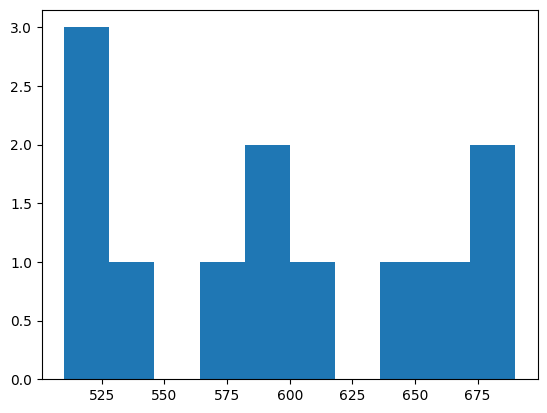

In [9]:
plt.hist(all_tokens)

In [10]:
np.mean(all_tokens)

np.float64(593.5)

In [47]:
def compute_scores_and_tokens(objectives_dfs, framework):
    all_tokens = []
    all_scores = []
    all_num_objs = [1, 2, 4, 8, 16]
    for num_objs in all_num_objs:
        traj_rewards = objectives_dfs[num_objs].groupby('traj_uid').rewards.max()
        all_scores.append(traj_rewards)
        peak_tokens = compute_peak_token_all_trajectories(objectives_dfs[num_objs], framework)
        all_tokens.append(peak_tokens)
    return all_tokens, all_scores

In [48]:
tokens, scores = compute_scores_and_tokens(abbel_objectives_dfs, 'ABBEL')

In [49]:
mtokens, mscores = compute_scores_and_tokens(objectives_dfs, 'MEM1')

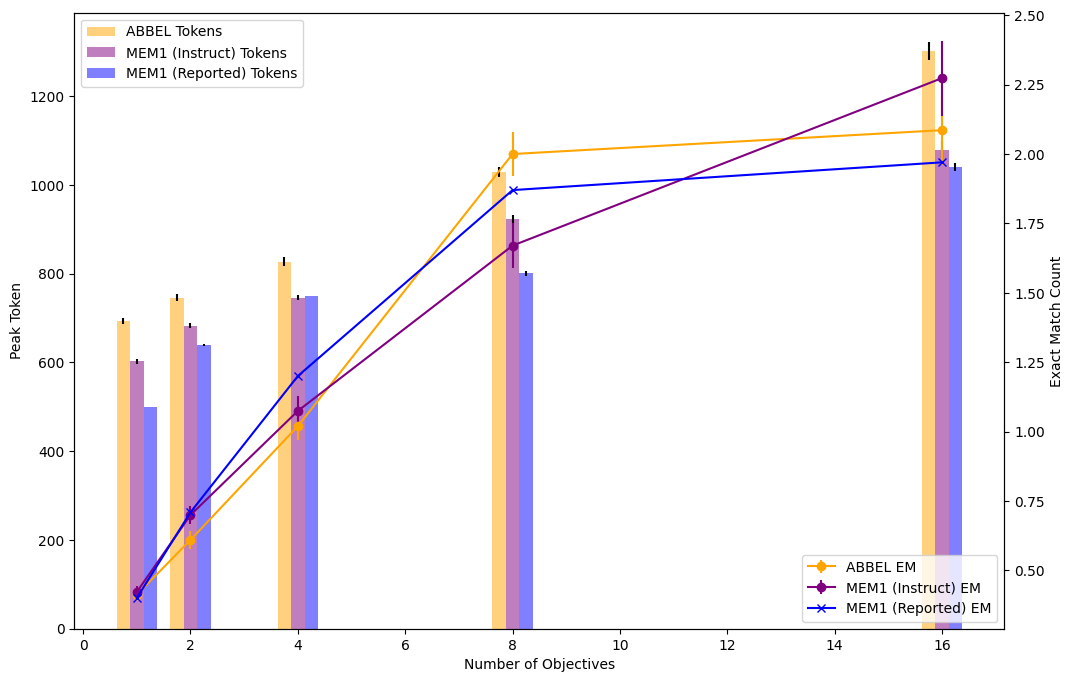

In [22]:
all_num_objs = [1, 2, 4, 8, 16]
plt.figure(figsize=(12, 8))
x_pos = np.array(all_num_objs)
width = 0.25
plt.bar(x_pos - width, [np.mean(t) for t in tokens], yerr=[np.std(t)/np.sqrt(len(t)) for t in tokens], width=width, alpha=0.5, label='ABBEL Tokens', color='orange')
plt.bar(x_pos , [np.mean(t) for t in mtokens], yerr=[np.std(t)/np.sqrt(len(t)) for t in mtokens], width=width, alpha=0.5, label='MEM1 (Instruct) Tokens', color='purple')
plt.bar(x_pos + width, [500,640,750,801,1040], yerr=[0,2,0,6,9], alpha=0.5, width=width, label='MEM1 (Reported) Tokens', color='blue')
plt.ylabel('Peak Token')
plt.xlabel('Number of Objectives')
plt.legend(loc='upper left')

# Create secondary y-axis for token means
ax2 = plt.gca().twinx()
ax2.errorbar(all_num_objs, [np.mean(s) for s in scores], yerr=[np.std(s)/np.sqrt(len(s)) for s in scores], marker='o', label='ABBEL EM', color='orange')
ax2.errorbar(all_num_objs, [np.mean(s) for s in mscores], yerr=[np.std(s)/np.sqrt(len(s)) for s in mscores], marker='o', label='MEM1 (Instruct) EM', color='purple')
ax2.errorbar(all_num_objs, [0.4,0.709,1.2,1.87,1.97], marker='x', label='MEM1 (Reported) EM', color='blue')
ax2.set_ylabel('Exact Match Count')
ax2.legend(loc='lower right')

plt.show()


In [69]:
abbel_objectives_dfs[16].groupby('traj_uid').size().mean()

np.float64(26.15625)

In [70]:
objectives_dfs[16].groupby('traj_uid').size().mean()

np.float64(15.375)

(array([ 1.,  0.,  0.,  1., 29., 76., 67., 29.,  7.,  1.]),
 array([  80. ,  181.9,  283.8,  385.7,  487.6,  589.5,  691.4,  793.3,
         895.2,  997.1, 1099. ]),
 <BarContainer object of 10 artists>)

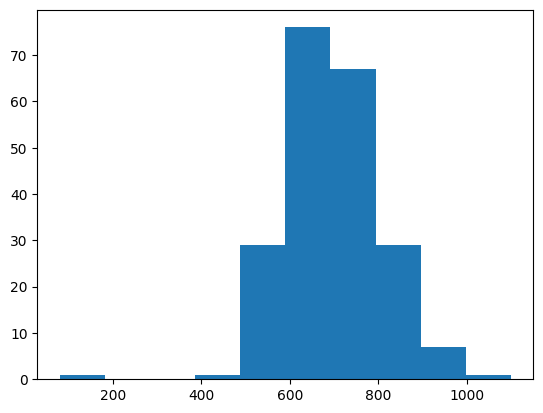

In [33]:
peak_tokens = []
for i, atraj in abbel_objectives_dfs[1].groupby('traj_uid'):
    if atraj.rewards.max() > 0:
        tokens = compute_peak_token_ABBEL(atraj.sort_values(by='step'))
        if tokens > 700:
            break
        peak_tokens.append(compute_peak_token_ABBEL(atraj.sort_values(by='step')))

plt.hist(peak_tokens)

In [40]:
peak_tokens = []
for i, atraj in abbel_objectives_dfs[1].groupby('traj_uid'):
    if atraj.rewards.max() > 0:
        tokens = compute_peak_token_ABBEL(atraj.sort_values(by='step'))
        if tokens > 1000:
            break

print(atraj.iloc[0].full_trajectory_strings)

system
You will answer multiple complex questions using iterative reasoning, and web search.
When taking an action, choose from one of the following actions:
   - If any question remains unanswered, issue a single query for one question inside <search> ... </search>. The query should consist of keywords or a short phrase. Only search one question at a time.
   - If all questions are answered, provide the final answers—separated by semicolons—within <answer> answer1; answer2; ... </answer>. The answers must be concise, contain only essential words, and avoid any explanations.

Important:
- Do not search multiple queries or questions simultaneously.

Answer the following questions: How many symphonies did Brahms compose?
user
Give me your first action. Remember to think before you act, as in <think> ... </think><search> ... </search> or <think> ... </think><answer> ... </answer>.
assistant
<think> To determine how many symphonies Brahms composed, I need to find an authoritative source th

(array([16., 46., 47., 40., 27., 13., 14.,  5.,  5.,  3.]),
 array([441. , 488.6, 536.2, 583.8, 631.4, 679. , 726.6, 774.2, 821.8,
        869.4, 917. ]),
 <BarContainer object of 10 artists>)

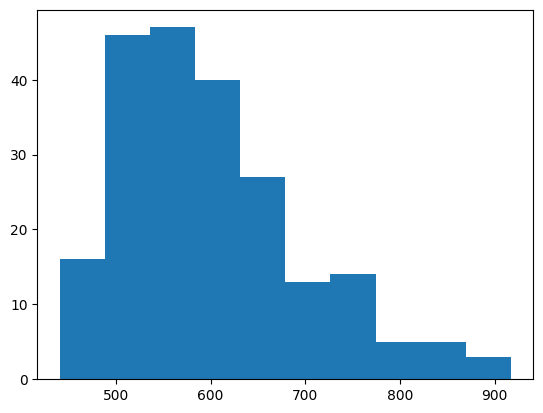

In [34]:
mem1_peak_tokens = []
for i, traj in objectives_dfs[1].groupby('traj_uid'):
    if traj.rewards.max() > 0:
        mem1_peak_tokens.append(compute_peak_token_MEM1(traj.sort_values(by='step')))

plt.hist(mem1_peak_tokens)

In [45]:
mem1_peak_tokens = []
count = 0
for i, traj in objectives_dfs[1].groupby('traj_uid'):
    if traj.rewards.max() > 0:
        tokens = compute_peak_token_MEM1(traj.sort_values(by='step'))
        if tokens > 600:
            count += 1
            if count > 1:
                break

print(traj.iloc[0].full_trajectory_strings)
# for i, row in traj.iterrows():
#     if row.step == 0:
#         continue
#     else:
#         input_str = row.input_ids_str.split('assistant\n')[1] # remove initial instructions/global prompt
#         input_IS = extract_tag_text(input_str, 'think') # previous internal state
#         input_action = extract_tag_text(input_str, 'search')
#         input_observation = extract_tag_text(input_str, 'information')
#         if '</hint>' in input_observation:
#             input_observation = input_observation.split('</hint>\n\n')[1]
#         input_str = input_IS + input_action + input_observation
#     output_str = row.response_ids_str
#     print(input_IS)
#     print(input_action)
#     print(input_observation)
#     print(output_str)
#     print('--------------------------------')

system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user
You will answer multiple complex questions using iterative reasoning, summarization, and web search.

At each step, you will see the questions, a cumulative summary of relevant information, the current search query, and search results (except in the first step, where only the questions are provided). Your task is to:

1. Perform reasoning and update a cumulative, concise summary within <think> ... </think>. This acts as persistent memory and must include all essential information from previous <think> and <information> tags.

2. Then choose one of the following actions:
   - If any question remains unanswered, issue a single query for one question inside <search> ... </search>. The query should consist of keywords or a short phrase. Only search one question at a time.
   - If all questions are answered, provide the final answers—separated by semicolons—within <answer> answer1; answer2; ... </answer>. The a

In [22]:
for i, traj in objectives_dfs[1].groupby('traj_uid'):
    if traj.rewards.max() > 0:
        pprint(extract_tag_text(traj[traj.step==0].iloc[0].input_ids_str.split('assistant\n')[1], 'think'))
        print(traj[traj.step==1].iloc[0].input_ids_str)
        break
        print('--------------------------------')


''
system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user
You will answer multiple complex questions using iterative reasoning, summarization, and web search.

At each step, you will see the questions, a cumulative summary of relevant information, the current search query, and search results (except in the first step, where only the questions are provided). Your task is to:

1. Perform reasoning and update a cumulative, concise summary within <think> ... </think>. This acts as persistent memory and must include all essential information from previous <think> and <information> tags.

2. Then choose one of the following actions:
   - If any question remains unanswered, issue a single query for one question inside <search> ... </search>. The query should consist of keywords or a short phrase. Only search one question at a time.
   - If all questions are answered, provide the final answers—separated by semicolons—within <answer> answer1; answer2; ... </answer>. Th

In [30]:
compute_peak_token_ABBEL(atraj.sort_values(by='step'))

591

In [31]:
compute_peak_token_MEM1(traj.sort_values(by='step'))

654

In [27]:
print(atraj.iloc[0].full_trajectory_strings)

system
You will answer multiple complex questions using iterative reasoning, and web search.
When taking an action, choose from one of the following actions:
   - If any question remains unanswered, issue a single query for one question inside <search> ... </search>. The query should consist of keywords or a short phrase. Only search one question at a time.
   - If all questions are answered, provide the final answers—separated by semicolons—within <answer> answer1; answer2; ... </answer>. The answers must be concise, contain only essential words, and avoid any explanations.

Important:
- Do not search multiple queries or questions simultaneously.

Answer the following questions: Bartlett's Bridge was built by the engineer who worked for the county seat of which Massachusetts county?
user
Give me your first action. Remember to think before you act, as in <think> ... </think><search> ... </search> or <think> ... </think><answer> ... </answer>.
assistant
<think> To determine which Massac

In [25]:
print(traj.iloc[0].full_trajectory_strings)

system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user
You will answer multiple complex questions using iterative reasoning, summarization, and web search.

At each step, you will see the questions, a cumulative summary of relevant information, the current search query, and search results (except in the first step, where only the questions are provided). Your task is to:

1. Perform reasoning and update a cumulative, concise summary within <think> ... </think>. This acts as persistent memory and must include all essential information from previous <think> and <information> tags.

2. Then choose one of the following actions:
   - If any question remains unanswered, issue a single query for one question inside <search> ... </search>. The query should consist of keywords or a short phrase. Only search one question at a time.
   - If all questions are answered, provide the final answers—separated by semicolons—within <answer> answer1; answer2; ... </answer>. The a

In [43]:
pprint(extract_tag_text(objectives_dfs[16][objectives_dfs[16].step==19].iloc[3].input_ids_str.split('assistant\n')[1], 'think'))

('The January 2, 2012 game featuring the University of Louisville team was '
 'likely played at the KFC Yum! Center, as it was the home venue for the '
 "Louisville Cardinals men's basketball team during the 2011–12 season. The "
 'KFC Yum! Center is located in Louisville, Kentucky, not in California, so '
 'Bubblegum Alley is not in the same location as the Gum Wall in Seattle.')


In [ ]:
for _, traj_df in objectives_dfs[16].groupby('traj_uid'):
    for i,row in traj_df.iterrows():
        if row.step == 0:
            input_str = ""
        else:
            input_str = row.input_ids_str.split('</instruction>\n')[1] # remove initial instructions/global prompt
            input_belief = extract_tag_text(input_str, 'think') # previous internal state
            input_action = extract_tag_text(input_str, 'search')
            input_observation = extract_tag_text(input_str, 'information')
            if '</hint>' in input_str:
                input_observation = input_observation.split('</hint>\n\n')[1]
            input_str = input_belief + input_action + input_observation
           
        output_str = row.response_ids_str
        peak_count = max(peak_count, len(tokenizer.encode(input_str + output_str)))

system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user
You will answer multiple complex questions using iterative reasoning, summarization, and web search.

At each step, you will see the questions, a cumulative summary of relevant information, the current search query, and search results (except in the first step, where only the questions are provided). Your task is to:

1. Perform reasoning and update a cumulative, concise summary within <think> ... </think>. This acts as persistent memory and must include all essential information from previous <think> and <information> tags.

2. Then choose one of the following actions:
   - If any question remains unanswered, issue a single query for one question inside <search> ... </search>. The query should consist of keywords or a short phrase. Only search one question at a time.
   - If all questions are answered, provide the final answers—separated by semicolons—within <answer> answer1; answer2; ... </answer>. The a

In [81]:
traj_df.iloc[0]['info']

{'attempt': 1,
 'target': [['Southern Baptist Theological Seminary'], ['1975']],
 'won': False,
 'action_or_belief': 0,
 'is_action_valid': 1}

In [55]:
pprint(traj_df.iloc[2].input_ids_str.split('</instruction>\n')[1])

('Current belief: <belief>Paul R. House attended Boyce College located in '
 'Louisville, Kentucky. No further searches required as all questions can be '
 'answered based on the current knowledge.</belief>\n'
 'Now think step by step and then output your next action formatted as <think> '
 '... </think><search> ... </search> or <think> ... </think><answer> ... '
 '</answer>.\n'
 'assistant\n')


In [56]:
pprint(traj_df.iloc[2].response_ids_str)

('<think> The questions provided are:\n'
 '1. What Bible college located in Louisville, Kentucky, was attended by Paul '
 'R. House who served for a time as president of the Evangelical Theological '
 'Society?\n'
 '2. Joan Jett & the Blackhearts covered a song by the first westerner to '
 'achieve pop star status in Japan. When was that song first recorded?\n'
 '\n'
 'Based on the current belief, the first question can be answered immediately '
 'as Boyce College. For the second question, no keywords or short phrases can '
 'be provided without additional context, so a search is required to identify '
 'the song covered by Joan Jett & the Blackhearts and the date of its first '
 'recording.</think>\n'
 '<search> first westerner to achieve pop star status in japan </search>')


In [77]:
print(traj_df.iloc[0].raw_prompt[1]['content'])


Give me your first action. Remember to think before you act, as in <think> ... </think><search> ... </search> or <think> ... </think><answer> ... </answer>.


In [87]:
peak_count = 0
for i,row in traj_df.iterrows():
    if i == 0:
        input_str = ""
    else:
        input_str = row.input_ids_str.split('</instruction>\n')[1] # remove initial instructions/global prompt
        if row['info']['action_or_belief'] == 1: # belief update step
            input_belief = extract_tag_text(input_str, 'belief')
            input_action = extract_tag_text(input_str, 'search')
            input_observation = extract_tag_text(input_str, 'observation')
            input_str = input_belief + input_action + input_observation
        else:
            input_str = extract_tag_text(input_str, 'belief')
    output_str = row.response_ids_str
    peak_count = max(peak_count, len(tokenizer.encode(input_str + output_str)))
    print('max peak count at row ', i, ' is ', peak_count)
    print(row['info']['action_or_belief'])

max peak count at row  0  is  84
0
max peak count at row  3  is  103
1
max peak count at row  4  is  183
0
max peak count at row  1  is  183
1
max peak count at row  2  is  183
0


In [59]:
pprint(input_str)

('Current belief: <belief>Paul R. House attended Boyce College located in '
 'Louisville, Kentucky. Alan Merrill is the first westerner to achieve pop '
 'star status in Japan, and he first recorded "I Love Rock \'n\' Roll" in '
 '1975. No further searches are required since all questions can be answered '
 'based on the current knowledge.</belief>\n'
 'Now think step by step and then output your next action formatted as <think> '
 '... </think><search> ... </search> or <think> ... </think><answer> ... '
 '</answer>.\n'
 'assistant\n')


In [60]:
pprint(output_str)

('<think> The current belief states that Paul R. House attended Boyce College, '
 'which is correctly located in Louisville, Kentucky. For the second question, '
 'the belief states that Alan Merrill is the first westerner to achieve pop '
 'star status in Japan and recorded "I Love Rock \'n\' Roll" in 1975. No '
 'further searches are required since all questions can be answered based on '
 'the current knowledge.</think>\n'
 '<answer> Boyce College; 1975 </answer>')


In [ ]:
def compute_peak_token_MEM1(traj_df) -> float:
    if traj_df.iloc[-1].rewards == 0:
        return None
    peak_count = 0
    solution_str = ""
    for step, row in traj_df.iterrows():
        new_solution_str = ""
        if f"t{i}" in data:
            solution_str += data[f"t{i}"] # t is Internal State (between <think> tags)
            new_solution_str += data[f"t{i}"] 
        if f"r{i}" in data:
            solution_str += data[f"r{i}"] # r is action (the response between <answer> or <query> tags)
            new_solution_str += data[f"r{i}"]
        
        peak_count = max(peak_count, len(tokenizer.encode(solution_str)))
        solution_str = new_solution_str
        if f"i{i}" in data:
            solution_str += data[f"i{i}"] # i is the Info returned by the RAG

    if peak_count == 0:
        return None

    return peak_count

In [ ]:
def compute_score(question, solution_str, ground_truths, val_type='f1',cot=False) -> float:
    solution_str = solution_str.lower()
    if cot == True:
        solution_str = solution_str + "</answer>"
    solution_str = solution_str.split("<|im_start|>assistant")[-1]

    if not check_tags_balance(solution_str):
        return -0.0
    try:
        answer_match = re.search(r'<answer>(.*?)</answer>', solution_str, re.DOTALL)
        if answer_match:
            answer_content = answer_match.group(1).strip()
        else:
            return -0.0
    except Exception as e:
        print(f"Error extracting answer content: {e}")
        return -0.0
    
    answers = answer_content.split(";")
    answers = [preprocess_text(answer) for answer in answers]

    max_score = 0.0

    if len(answers) != len(ground_truths):
        return max_score

    for idx, answer in enumerate(answers):
        cur_max_score = 0.0
        gts = ground_truths[idx]
        gts = [preprocess_text(gt) for gt in gts]
    
        if val_type == 'em' or val_type == "mbe":
            if answer in gts:
                cur_max_score = 1.0
        else:
            for gt in gts:
                pred_tokens = set(answer.split())
                gt_tokens = set(gt.split())
                
                if not gt_tokens:
                    continue
                if not pred_tokens:
                    continue
                
                common_tokens = pred_tokens & gt_tokens
                
                precision = len(common_tokens) / len(pred_tokens) if pred_tokens else 0
                recall = len(common_tokens) / len(gt_tokens) if gt_tokens else 0
                
                if precision + recall > 0:
                    f1 = 2 * (precision * recall) / (precision + recall)
                    cur_max_score = max(cur_max_score, f1)

        max_score += cur_max_score
        if val_type == "mbe":
            # max_score = get_mbe_result(question,ground_truths,answer_content)
            return 0

    return max_score